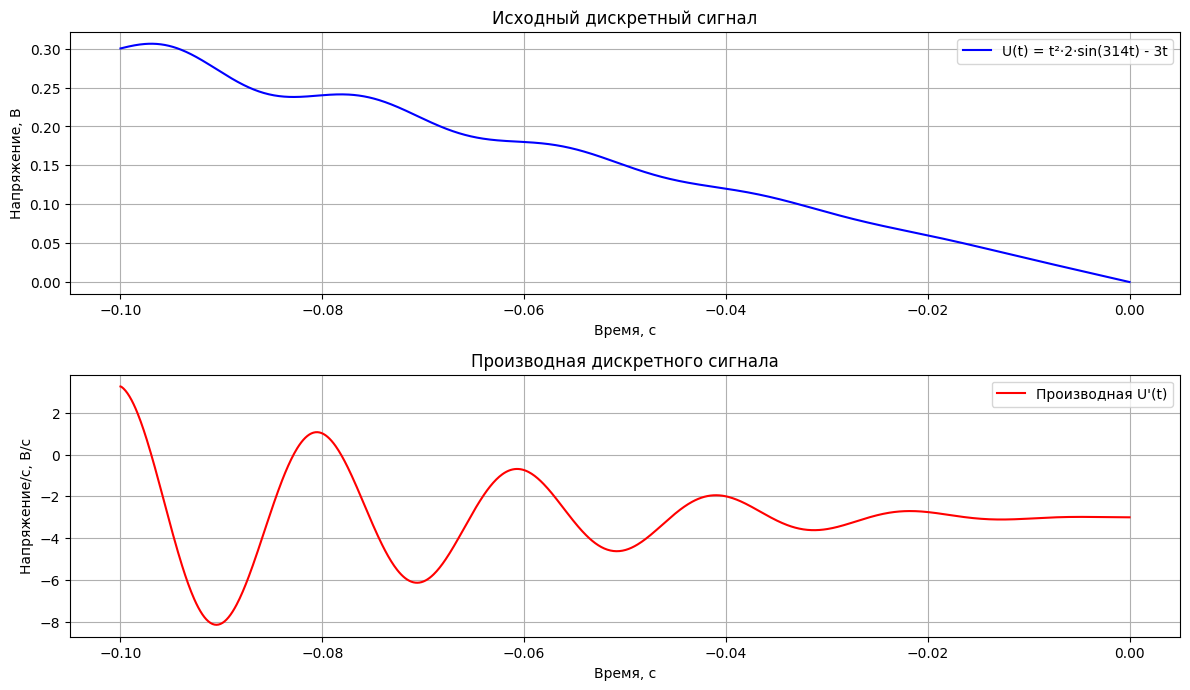

Результат расчета интеграла сигнала: 0.015064 В·с

Тестирование функций:
Константная функция f(t) = 5:
  Средняя производная: 0.000000 (ожидается: 0.000)
  Интеграл: 5.000000 (ожидается: 5.000)
Линейная функция f(t) = 2t + 1:
  Средняя производная: 2.000000 (ожидается: 2.000)
  Интеграл: 2.000000 (ожидается: 2.000)
Квадратичная функция f(t) = t²:
  Производная в конечной точке: 1.989899 (ожидается: 2.000)
  Интеграл: 0.333350 (ожидается: 0.333)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Функция для создания тестового дискретного сигнала
def create_signal(t):
    """
    Создает дискретный сигнал U(t) = t^2 * 2 * sin(t * 314) - t * 3
    """
    return t**2 * 2 * np.sin(t * 314) - t * 3

# 2. Функция для численного дифференцирования (производная)
def derivative(t, signal):
    """
    Вычисляет производную дискретного сигнала методом центральной разности
    """
    dt = t[1] - t[0]  # шаг дискретизации
    deriv = np.zeros(len(t))
    
    # Для внутренних точек используем центральную разность
    for i in range(1, len(t) - 1):
        deriv[i] = (signal[i + 1] - signal[i - 1]) / (2 * dt)
    
    # Для граничных точек используем односторонние разности
    deriv[0] = (signal[1] - signal[0]) / dt
    deriv[-1] = (signal[-1] - signal[-2]) / dt
    
    return deriv

# 3. Функция для численного интегрирования (интеграл)
def integrate(t, signal):
    """
    Вычисляет интеграл дискретного сигнала методом трапеций
    """
    dt = t[1] - t[0]  # шаг дискретизации
    integral = 0
    
    for i in range(len(t) - 1):
        integral += (signal[i] + signal[i + 1]) * dt / 2
    
    return integral

# Параметры сигнала
fs = 1000  # уменьшим частоту дискретизации для наглядности
t_start, t_end = -0.1, 0  # уменьшим диапазон времени
num_points = 1000  # фиксированное количество точек

# Создание временной оси
t = np.linspace(t_start, t_end, num_points)

# Создание тестового сигнала
U = create_signal(t)

# Вычисление производной
U_derivative = derivative(t, U)

# Вычисление интеграла
U_integral = integrate(t, U)

# Построение графиков
plt.figure(figsize=(12, 10))

# График исходного сигнала
plt.subplot(3, 1, 1)
plt.plot(t, U, 'b-', linewidth=1.5, label='U(t) = t²·2·sin(314t) - 3t')
plt.xlabel('Время, с')
plt.ylabel('Напряжение, В')
plt.title('Исходный дискретный сигнал')
plt.grid(True)
plt.legend()

# График производной сигнала
plt.subplot(3, 1, 2)
plt.plot(t, U_derivative, 'r-', linewidth=1.5, label='Производная U\'(t)')
plt.xlabel('Время, с')
plt.ylabel('Напряжение/с, В/с')
plt.title('Производная дискретного сигнала')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Вывод результата расчета интеграла
print(f"Результат расчета интеграла сигнала: {U_integral:.6f} В·с")

# Тестирование на простых функциях
print("\nТестирование функций:")

# Тест 1: Константная функция f(t) = 5
t_test = np.linspace(0, 1, 100)
f_const = np.ones_like(t_test) * 5

# Аналитическая производная: f'(t) = 0
# Аналитический интеграл на [0,1]: ∫5dt = 5t |₀¹ = 5

deriv_const = derivative(t_test, f_const)
integral_const = integrate(t_test, f_const)

print(f"Константная функция f(t) = 5:")
print(f"  Средняя производная: {np.mean(deriv_const):.6f} (ожидается: 0.000)")
print(f"  Интеграл: {integral_const:.6f} (ожидается: 5.000)")

# Тест 2: Линейная функция f(t) = 2t + 1
f_linear = 2 * t_test + 1

# Аналитическая производная: f'(t) = 2
# Аналитический интеграл на [0,1]: ∫(2t+1)dt = t² + t |₀¹ = 1 + 1 = 2

deriv_linear = derivative(t_test, f_linear)
integral_linear = integrate(t_test, f_linear)

print(f"Линейная функция f(t) = 2t + 1:")
print(f"  Средняя производная: {np.mean(deriv_linear[1:-1]):.6f} (ожидается: 2.000)")
print(f"  Интеграл: {integral_linear:.6f} (ожидается: 2.000)")

# Тест 3: Квадратичная функция f(t) = t²
f_quad = t_test**2

# Аналитическая производная: f'(t) = 2t
# Аналитический интеграл на [0,1]: ∫t²dt = t³/3 |₀¹ = 1/3 ≈ 0.333

deriv_quad = derivative(t_test, f_quad)
integral_quad = integrate(t_test, f_quad)

print(f"Квадратичная функция f(t) = t²:")
print(f"  Производная в конечной точке: {deriv_quad[-1]:.6f} (ожидается: 2.000)")
print(f"  Интеграл: {integral_quad:.6f} (ожидается: 0.333)")

In [5]:
def dsignal (t):
    return (t**2)*2*numpy.sin(314*t)-3*t

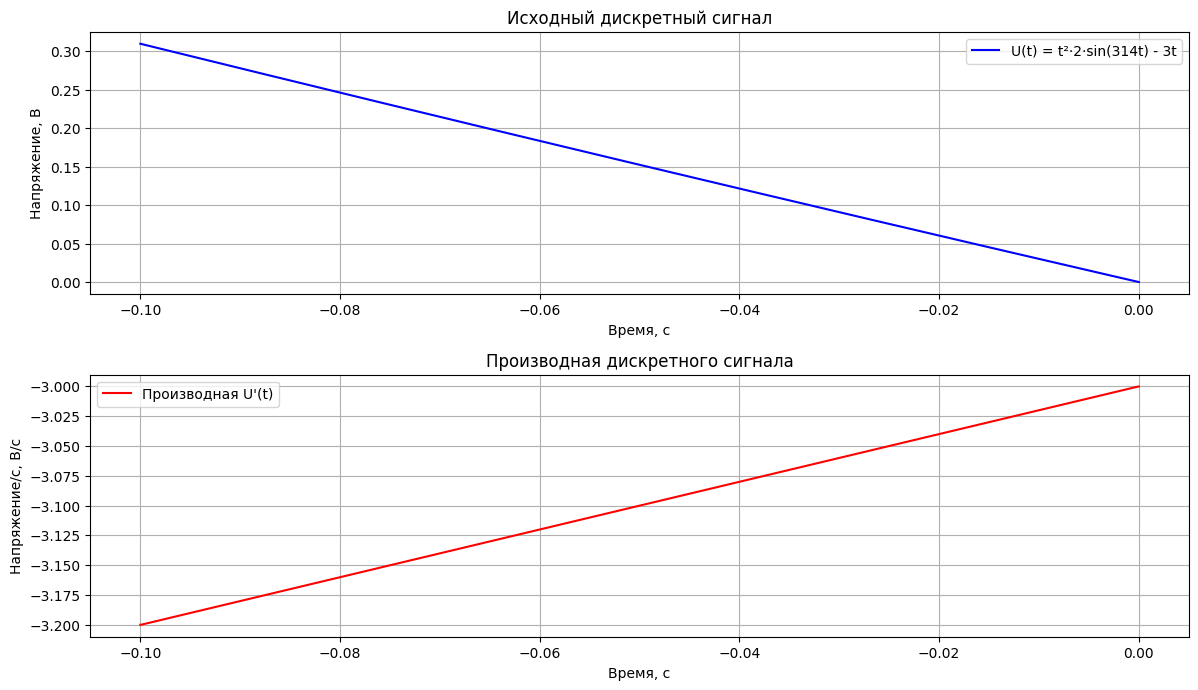

Результат расчета интеграла сигнала: 0.015333 В·с

Тестирование функций:
Константная функция f(t) = 5:
  Средняя производная: 0.000000 (ожидается: 0.000)
  Интеграл: 5.000000 (ожидается: 5.000)
Линейная функция f(t) = 2t + 1:
  Средняя производная: 2.000000 (ожидается: 2.000)
  Интеграл: 2.000000 (ожидается: 2.000)
Квадратичная функция f(t) = t²:
  Производная в конечной точке: 1.989899 (ожидается: 2.000)
  Интеграл: 0.333350 (ожидается: 0.333)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Функция для создания тестового дискретного сигнала
def create_signal(t):
    """
    Создает дискретный сигнал U(t) = t^2 * 2 * sin(t * 314) - t * 3
    """
    return t**2- t * 3

# 2. Функция для численного дифференцирования (производная)
def derivative(t, signal):
    """
    Вычисляет производную дискретного сигнала методом центральной разности
    """
    dt = t[1] - t[0]  # шаг дискретизации
    deriv = np.zeros(len(t))
    
    # Для внутренних точек используем центральную разность
    for i in range(1, len(t) - 1):
        deriv[i] = (signal[i + 1] - signal[i - 1]) / (2 * dt)
    
    # Для граничных точек используем односторонние разности
    deriv[0] = (signal[1] - signal[0]) / dt
    deriv[-1] = (signal[-1] - signal[-2]) / dt
    
    return deriv

# 3. Функция для численного интегрирования (интеграл)
def integrate(t, signal):
    """
    Вычисляет интеграл дискретного сигнала методом трапеций
    """
    dt = t[1] - t[0]  # шаг дискретизации
    integral = 0
    
    for i in range(len(t) - 1):
        integral += (signal[i] + signal[i + 1]) * dt / 2
    
    return integral

# Параметры сигнала
fs = 1000  # уменьшим частоту дискретизации для наглядности
t_start, t_end = -0.1, 0  # уменьшим диапазон времени
num_points = 1000  # фиксированное количество точек

# Создание временной оси
t = np.linspace(t_start, t_end, num_points)

# Создание тестового сигнала
U = create_signal(t)

# Вычисление производной
U_derivative = derivative(t, U)

# Вычисление интеграла
U_integral = integrate(t, U)

# Построение графиков
plt.figure(figsize=(12, 10))

# График исходного сигнала
plt.subplot(3, 1, 1)
plt.plot(t, U, 'b-', linewidth=1.5, label='U(t) = t²·2·sin(314t) - 3t')
plt.xlabel('Время, с')
plt.ylabel('Напряжение, В')
plt.title('Исходный дискретный сигнал')
plt.grid(True)
plt.legend()

# График производной сигнала
plt.subplot(3, 1, 2)
plt.plot(t, U_derivative, 'r-', linewidth=1.5, label='Производная U\'(t)')
plt.xlabel('Время, с')
plt.ylabel('Напряжение/с, В/с')
plt.title('Производная дискретного сигнала')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Вывод результата расчета интеграла
print(f"Результат расчета интеграла сигнала: {U_integral:.6f} В·с")

# Тестирование на простых функциях
print("\nТестирование функций:")

# Тест 1: Константная функция f(t) = 5
t_test = np.linspace(0, 1, 100)
f_const = np.ones_like(t_test) * 5

# Аналитическая производная: f'(t) = 0
# Аналитический интеграл на [0,1]: ∫5dt = 5t |₀¹ = 5

deriv_const = derivative(t_test, f_const)
integral_const = integrate(t_test, f_const)

print(f"Константная функция f(t) = 5:")
print(f"  Средняя производная: {np.mean(deriv_const):.6f} (ожидается: 0.000)")
print(f"  Интеграл: {integral_const:.6f} (ожидается: 5.000)")

# Тест 2: Линейная функция f(t) = 2t + 1
f_linear = 2 * t_test + 1

# Аналитическая производная: f'(t) = 2
# Аналитический интеграл на [0,1]: ∫(2t+1)dt = t² + t |₀¹ = 1 + 1 = 2

deriv_linear = derivative(t_test, f_linear)
integral_linear = integrate(t_test, f_linear)

print(f"Линейная функция f(t) = 2t + 1:")
print(f"  Средняя производная: {np.mean(deriv_linear[1:-1]):.6f} (ожидается: 2.000)")
print(f"  Интеграл: {integral_linear:.6f} (ожидается: 2.000)")

# Тест 3: Квадратичная функция f(t) = t²
f_quad = t_test**2

# Аналитическая производная: f'(t) = 2t
# Аналитический интеграл на [0,1]: ∫t²dt = t³/3 |₀¹ = 1/3 ≈ 0.333

deriv_quad = derivative(t_test, f_quad)
integral_quad = integrate(t_test, f_quad)

print(f"Квадратичная функция f(t) = t²:")
print(f"  Производная в конечной точке: {deriv_quad[-1]:.6f} (ожидается: 2.000)")
print(f"  Интеграл: {integral_quad:.6f} (ожидается: 0.333)")

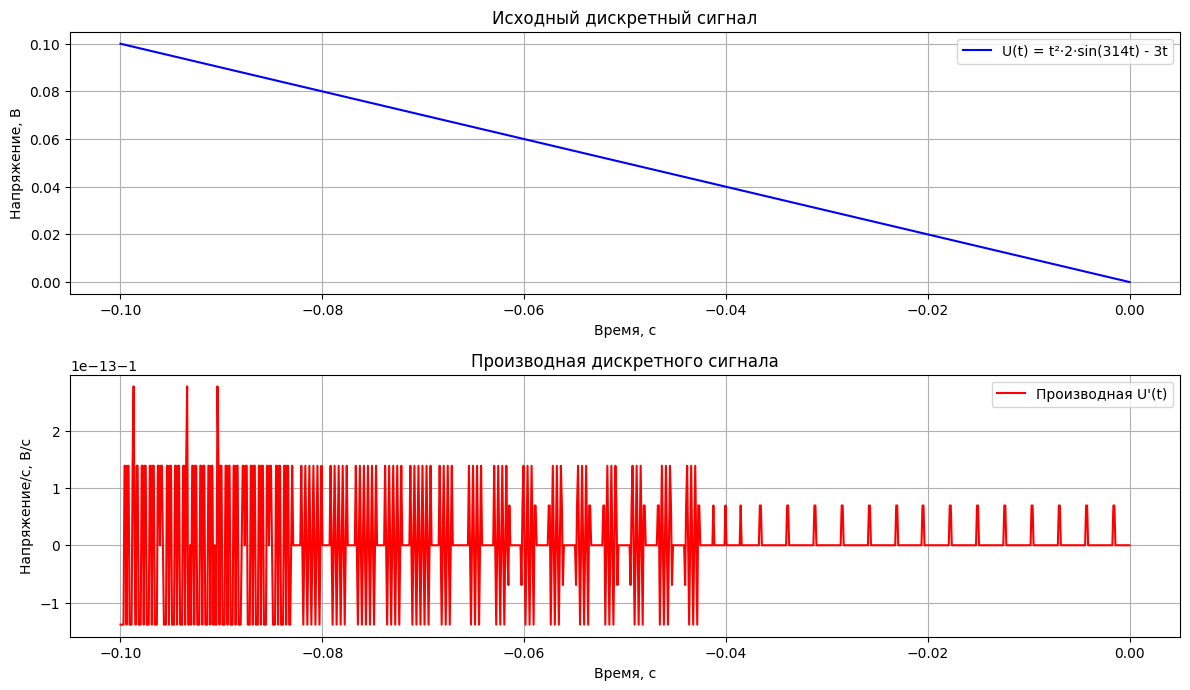

Результат расчета интеграла сигнала: 0.005000 В·с

Тестирование функций:
Константная функция f(t) = 5:
  Средняя производная: 0.000000 (ожидается: 0.000)
  Интеграл: 5.000000 (ожидается: 5.000)
Линейная функция f(t) = 2t + 1:
  Средняя производная: 2.000000 (ожидается: 2.000)
  Интеграл: 2.000000 (ожидается: 2.000)
Квадратичная функция f(t) = t²:
  Производная в конечной точке: 1.989899 (ожидается: 2.000)
  Интеграл: 0.333350 (ожидается: 0.333)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Функция для создания тестового дискретного сигнала
def create_signal(t):
    """
    Создает дискретный сигнал U(t) = t^2 * 2 * sin(t * 314) - t * 3
    """
    return t*2- t * 3

# 2. Функция для численного дифференцирования (производная)
def derivative(t, signal):
    """
    Вычисляет производную дискретного сигнала методом центральной разности
    """
    dt = t[1] - t[0]  # шаг дискретизации
    deriv = np.zeros(len(t))
    
    # Для внутренних точек используем центральную разность
    for i in range(1, len(t) - 1):
        deriv[i] = (signal[i + 1] - signal[i - 1]) / (2 * dt)
    
    # Для граничных точек используем односторонние разности
    deriv[0] = (signal[1] - signal[0]) / dt
    deriv[-1] = (signal[-1] - signal[-2]) / dt
    
    return deriv

# 3. Функция для численного интегрирования (интеграл)
def integrate(t, signal):
    """
    Вычисляет интеграл дискретного сигнала методом трапеций
    """
    dt = t[1] - t[0]  # шаг дискретизации
    integral = 0
    
    for i in range(len(t) - 1):
        integral += (signal[i] + signal[i + 1]) * dt / 2
    
    return integral

# Параметры сигнала
fs = 1000  # уменьшим частоту дискретизации для наглядности
t_start, t_end = -0.1, 0  # уменьшим диапазон времени
num_points = 1000  # фиксированное количество точек

# Создание временной оси
t = np.linspace(t_start, t_end, num_points)

# Создание тестового сигнала
U = create_signal(t)

# Вычисление производной
U_derivative = derivative(t, U)

# Вычисление интеграла
U_integral = integrate(t, U)

# Построение графиков
plt.figure(figsize=(12, 10))

# График исходного сигнала
plt.subplot(3, 1, 1)
plt.plot(t, U, 'b-', linewidth=1.5, label='U(t) = t²·2·sin(314t) - 3t')
plt.xlabel('Время, с')
plt.ylabel('Напряжение, В')
plt.title('Исходный дискретный сигнал')
plt.grid(True)
plt.legend()

# График производной сигнала
plt.subplot(3, 1, 2)
plt.plot(t, U_derivative, 'r-', linewidth=1.5, label='Производная U\'(t)')
plt.xlabel('Время, с')
plt.ylabel('Напряжение/с, В/с')
plt.title('Производная дискретного сигнала')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Вывод результата расчета интеграла
print(f"Результат расчета интеграла сигнала: {U_integral:.6f} В·с")

# Тестирование на простых функциях
print("\nТестирование функций:")

# Тест 1: Константная функция f(t) = 5
t_test = np.linspace(0, 1, 100)
f_const = np.ones_like(t_test) * 5

# Аналитическая производная: f'(t) = 0
# Аналитический интеграл на [0,1]: ∫5dt = 5t |₀¹ = 5

deriv_const = derivative(t_test, f_const)
integral_const = integrate(t_test, f_const)

print(f"Константная функция f(t) = 5:")
print(f"  Средняя производная: {np.mean(deriv_const):.6f} (ожидается: 0.000)")
print(f"  Интеграл: {integral_const:.6f} (ожидается: 5.000)")

# Тест 2: Линейная функция f(t) = 2t + 1
f_linear = 2 * t_test + 1

# Аналитическая производная: f'(t) = 2
# Аналитический интеграл на [0,1]: ∫(2t+1)dt = t² + t |₀¹ = 1 + 1 = 2

deriv_linear = derivative(t_test, f_linear)
integral_linear = integrate(t_test, f_linear)

print(f"Линейная функция f(t) = 2t + 1:")
print(f"  Средняя производная: {np.mean(deriv_linear[1:-1]):.6f} (ожидается: 2.000)")
print(f"  Интеграл: {integral_linear:.6f} (ожидается: 2.000)")

# Тест 3: Квадратичная функция f(t) = t²
f_quad = t_test**2

# Аналитическая производная: f'(t) = 2t
# Аналитический интеграл на [0,1]: ∫t²dt = t³/3 |₀¹ = 1/3 ≈ 0.333

deriv_quad = derivative(t_test, f_quad)
integral_quad = integrate(t_test, f_quad)

print(f"Квадратичная функция f(t) = t²:")
print(f"  Производная в конечной точке: {deriv_quad[-1]:.6f} (ожидается: 2.000)")
print(f"  Интеграл: {integral_quad:.6f} (ожидается: 0.333)")